# 🚦 Road Accident Severity Prediction
## Objective
Predict accident severity using ML models.

## Steps
1. Data Loading
2. Cleaning
3. Feature Engineering
4. Modeling
5. Evaluation


# 🚗 Road Accident Severity Prediction

## Business Problem
Road accidents are a leading cause of fatalities worldwide. Predicting accident severity in advance can help:
- **Traffic authorities** allocate emergency resources more effectively
- **Urban planners** identify high-risk zones for infrastructure improvements
- **Insurance companies** assess risk profiles more accurately

**Goal:** Build a machine learning model to classify accident severity (Slight / Serious / Fatal) based on road, vehicle, and environmental conditions.

**Dataset:** UK Road Accidents Dataset (Kaggle) — contains 600,000+ records with 33 features including weather, road type, vehicle details, and casualty information.

**Approach:**
1. Data Cleaning & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Selection
4. Model Training: Random Forest vs XGBoost
5. Model Comparison & SHAP Explainability
6. Conclusions & Business Insights

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import xgboost as xgb
import shap
import kagglehub
print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Dataset

Dataset source: [UK Road Accidents — Kaggle](https://www.kaggle.com/datasets/silicon99/dft-accident-data)

In [ ]:
# Download latest version
path = kagglehub.dataset_download("silicon99/dft-accident-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dft-accident-data' dataset.
Path to dataset files: /kaggle/input/dft-accident-data


In [ ]:
import os

base_path = "/kaggle/input/dft-accident-data"

print(os.listdir(base_path))  # see actual file names

['contextCSVs', 'Casualties0515.csv', 'Vehicles0515.csv', 'tidydata.sh', 'Accidents0515.csv']


In [ ]:
# Load dataset — update path if running locally
df = pd.read_csv(base_path + "/Accidents0515.csv")
df.head()

print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (1780653, 32)

First 5 rows:


,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,...,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location
0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,04/01/2005,...,0,1,1,2,2,0,0,1,1,E01002849
1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,05/01/2005,...,0,5,4,1,1,0,0,1,1,E01002909
2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,06/01/2005,...,0,0,4,1,1,0,0,1,1,E01002857
3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,07/01/2005,...,0,0,1,1,1,0,0,1,1,E01002840
4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,10/01/2005,...,0,0,7,1,2,0,0,1,1,E01002863


In [ ]:
# Parse date and keep as column (not index) for compatibility
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

print('Dataset Info:')
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780653 entries, 0 to 1780652
Data columns (total 32 columns):
 #   Column                                       Dtype         
---  ------                                       -----         
 0   Accident_Index                               object        
 1   Location_Easting_OSGR                        float64       
 2   Location_Northing_OSGR                       float64       
 3   Longitude                                    float64       
 4   Latitude                                     float64       
 5   Police_Force                                 int64         
 6   Accident_Severity                            int64         
 7   Number_of_Vehicles                           int64         
 8   Number_of_Casualties                         int64         
 9   Date                                         datetime64[ns]
 10  Day_of_Week                                  int64         
 11  Time                   

## 3. Data Cleaning & Preprocessing

In [ ]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Columns with missing values:')
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

Columns with missing values:
                           Missing Count  Missing %
LSOA_of_Accident_Location         129471   7.270984
Time                                 151   0.008480
Location_Northing_OSGR               138   0.007750
Location_Easting_OSGR                138   0.007750
Latitude                             138   0.007750
Longitude                            138   0.007750


In [ ]:
df2 = df.copy()

# Rename columns to lowercase with underscores for consistency
df.columns = [c.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('__', '_') for c in df.columns]
df2.columns = df.columns

# Replace -1 (missing code) with NaN
df = df.replace(-1, float('nan'))
df_processed = df.copy()

print('Columns cleaned. Shape:', df_processed.shape)
print('Columns:', list(df_processed.columns))


Columns cleaned. Shape: (1780653, 32)
Columns: ['accident_index', 'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'police_force', 'accident_severity', 'number_of_vehicles', 'number_of_casualties', 'date', 'day_of_week', 'time', 'local_authority_district', 'local_authority_highway', '1st_road_class', '1st_road_number', 'road_type', 'speed_limit', 'junction_detail', 'junction_control', '2nd_road_class', '2nd_road_number', 'pedestrian_crossing-human_control', 'pedestrian_crossing-physical_facilities', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'lsoa_of_accident_location']


In [ ]:
# Identify high-cardinality object columns for label encoding
label_encoder = LabelEncoder()
df_encoded = df_processed.copy()

cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
for feature in cat_cols:
    df_encoded[feature] = label_encoder.fit_transform(df_encoded[feature].astype(str))

# Drop ID-like columns if present
for drop_col in ['accident_index', 'location_easting_osgr', 'location_northing_osgr']:
    if drop_col in df_encoded.columns:
        df_encoded.drop(drop_col, axis=1, inplace=True)

# Drop rows with remaining NaN values
df_encoded.dropna(inplace=True)
df_encoded.reset_index(drop=True, inplace=True)

# Ensure target column exists
target_col = 'accident_severity' if 'accident_severity' in df_encoded.columns else None
print(f'After cleaning — shape: {df_encoded.shape}')
if target_col:
    print(f'Target distribution:\n{df_encoded[target_col].value_counts()}')
else:
    print('Available columns:', list(df_encoded.columns))


After cleaning — shape: (1045028, 29)
Target distribution:
accident_severity
3    910745
2    126182
1      8101
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

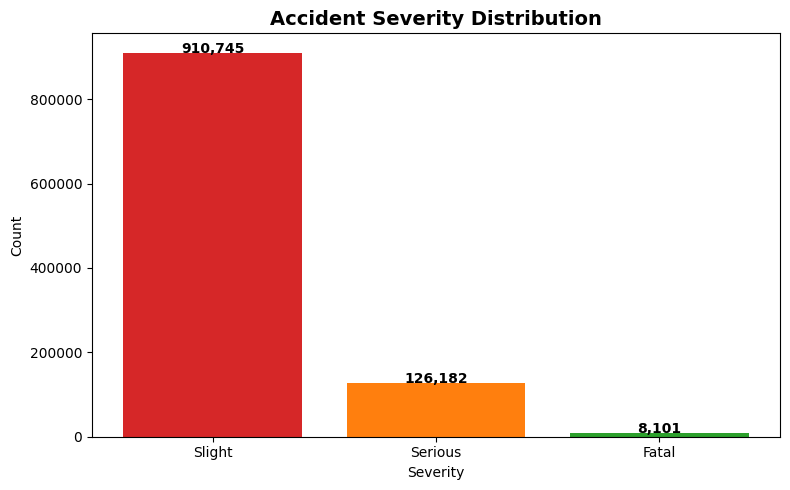


Key Insight: Dataset is heavily imbalanced — Slight accidents dominate.
This is expected in real-world road accident data.


In [ ]:
# Target variable distribution
plt.figure(figsize=(8, 5))
severity_map = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
counts = df_encoded['accident_severity'].value_counts()
bars = plt.bar([severity_map.get(i, i) for i in counts.index], counts.values,
               color=['#d62728', '#ff7f0e', '#2ca02c'])
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', fontweight='bold')
plt.title('Accident Severity Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('\nKey Insight: Dataset is heavily imbalanced — Slight accidents dominate.')
print('This is expected in real-world road accident data.')

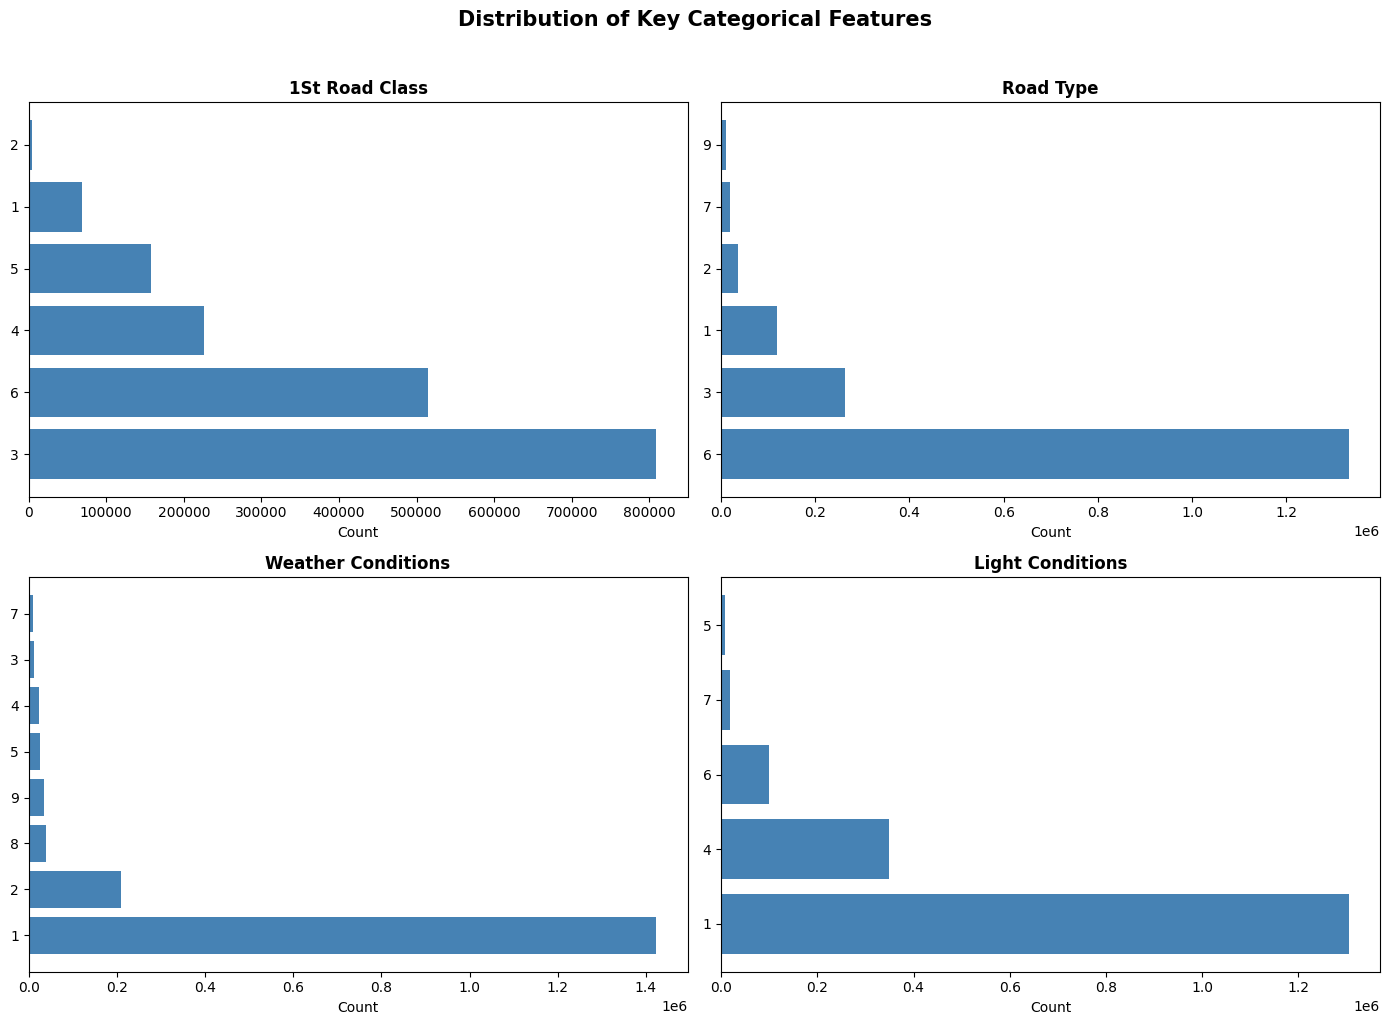

In [ ]:
# EDA: Categorical feature distributions
categorical_features_eda = [c for c in ['sex_of_driver', 'sex_of_casualty', 'vehicle_type', 'vehicle_manoeuvre',
                                           '1st_road_class', 'road_type', 'weather_conditions', 'light_conditions']
                            if c in df2.columns]

n = min(len(categorical_features_eda), 4)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx in range(4):
    if idx < n:
        feature = categorical_features_eda[idx]
        value_counts = df2[feature].value_counts().head(8)
        axes[idx].barh(value_counts.index.astype(str), value_counts.values, color='steelblue')
        axes[idx].set_title(f'{feature.replace("_", " ").title()}', fontweight='bold')
        axes[idx].set_xlabel('Count')
    else:
        axes[idx].set_visible(False)

plt.suptitle('Distribution of Key Categorical Features', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


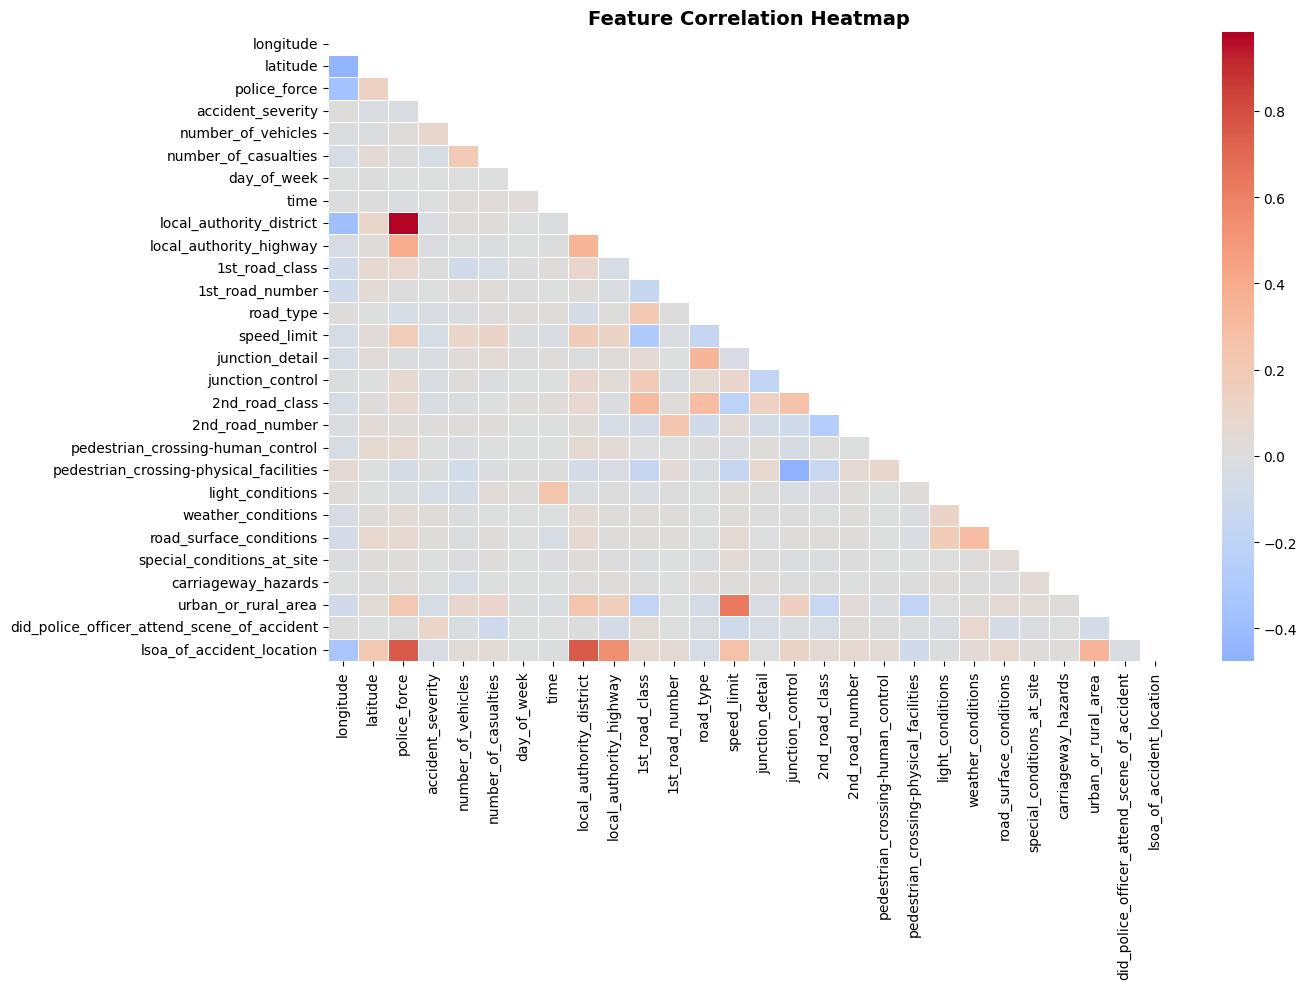

In [ ]:
# Correlation heatmap for numeric features
numeric_df = df_encoded.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Feature Selection

Using **LinearSVC with L1 penalty** to identify the most informative features. L1 regularization naturally zeroes out less important features, giving us a lean, interpretable feature set.

In [ ]:
# Prepare features and target
X = df_encoded.select_dtypes(include=['number']).drop('accident_severity', axis=1, errors='ignore')
y = df_encoded['accident_severity']

# Feature selection using LinearSVC
svc_classifier = LinearSVC(C=0.01, penalty='l1', dual=False, max_iter=2000)
feature_selector = SelectFromModel(estimator=svc_classifier)
feature_selector.fit(X, y)

feature_mask = feature_selector.get_support()
selected_features = X.columns[feature_mask].tolist()

print(f'Features selected: {len(selected_features)} out of {X.shape[1]}')
print(f'Selected features: {selected_features}')

# Build final feature matrix
X_selected = df_encoded[selected_features]
y_selected = df_encoded['accident_severity']

Features selected: 24 out of 27
Selected features: ['longitude', 'latitude', 'police_force', 'number_of_vehicles', 'number_of_casualties', 'day_of_week', 'time', 'local_authority_district', 'local_authority_highway', '1st_road_class', 'road_type', 'speed_limit', 'junction_detail', 'junction_control', '2nd_road_class', 'pedestrian_crossing-human_control', 'pedestrian_crossing-physical_facilities', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident']


## 6. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_selected, test_size=0.2, random_state=42, stratify=y_selected
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (836022, 24)
Test set:     (209006, 24)


## 7. Model 1 — Random Forest Classifier

Random Forest is an ensemble of decision trees using bagging. It is robust to overfitting, handles imbalanced data reasonably well, and provides native feature importance.

In [ ]:
# Train Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_train)

y_pred_rf = rf_classifier.predict(X_test)

# Metrics
rf_accuracy  = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall    = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1        = f1_score(y_test, y_pred_rf, average='weighted')

print('=== Random Forest Results ===')
print(f'Accuracy:  {rf_accuracy:.4f}')
print(f'Precision: {rf_precision:.4f}')
print(f'Recall:    {rf_recall:.4f}')
print(f'F1-Score:  {rf_f1:.4f}')

=== Random Forest Results ===
Accuracy:  0.8693
Precision: 0.7958
Recall:    0.8693
F1-Score:  0.8136


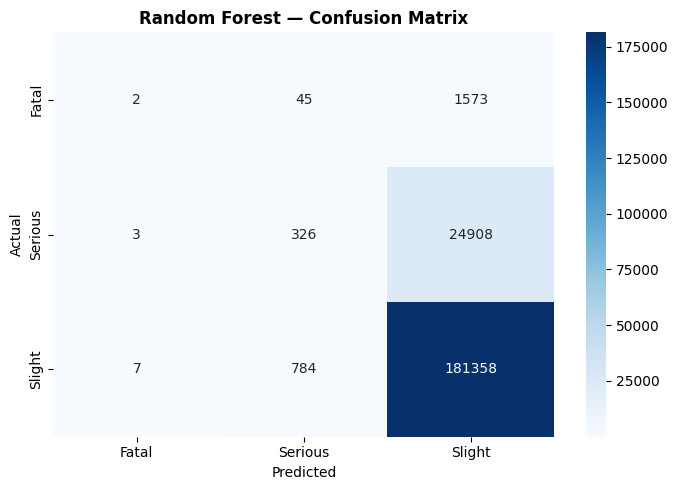


Classification Report:
              precision    recall  f1-score   support

       Fatal       0.17      0.00      0.00      1620
     Serious       0.28      0.01      0.02     25237
      Slight       0.87      1.00      0.93    182149

    accuracy                           0.87    209006
   macro avg       0.44      0.34      0.32    209006
weighted avg       0.80      0.87      0.81    209006



In [ ]:
# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fatal', 'Serious', 'Slight'],
            yticklabels=['Fatal', 'Serious', 'Slight'])
plt.title('Random Forest — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Fatal', 'Serious', 'Slight']))

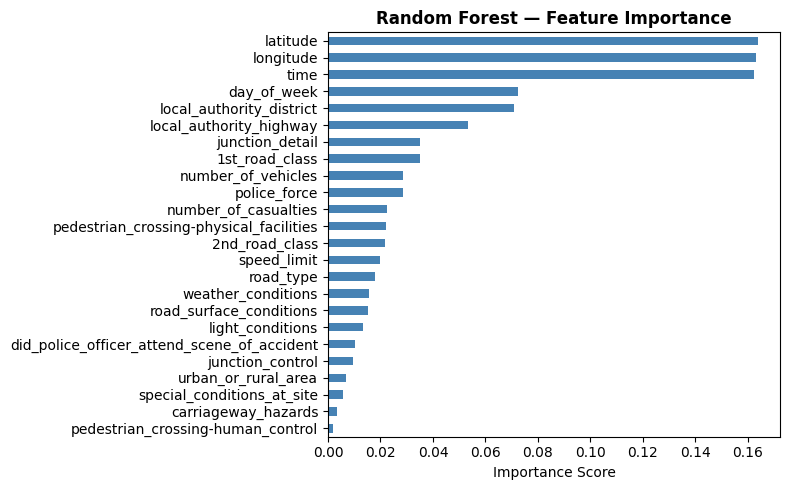

In [ ]:
# Feature Importance — Random Forest
importances = pd.Series(rf_classifier.feature_importances_, index=selected_features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 8. Model 2 — XGBoost Classifier

XGBoost is a gradient boosting algorithm that builds trees sequentially, each correcting errors of the previous. It is highly efficient, handles sparse data well, and consistently wins ML competitions on tabular data.

In [ ]:
# Encode labels to start from 0 (XGBoost requirement)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Train XGBoost
xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_classifier.fit(X_train, y_train_enc)

y_pred_xgb_enc = xgb_classifier.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

# Metrics
xgb_accuracy  = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, average='weighted')
xgb_recall    = recall_score(y_test, y_pred_xgb, average='weighted')
xgb_f1        = f1_score(y_test, y_pred_xgb, average='weighted')

print('=== XGBoost Results ===')
print(f'Accuracy:  {xgb_accuracy:.4f}')
print(f'Precision: {xgb_precision:.4f}')
print(f'Recall:    {xgb_recall:.4f}')
print(f'F1-Score:  {xgb_f1:.4f}')

=== XGBoost Results ===
Accuracy:  0.8715
Precision: 0.8148
Recall:    0.8715
F1-Score:  0.8125


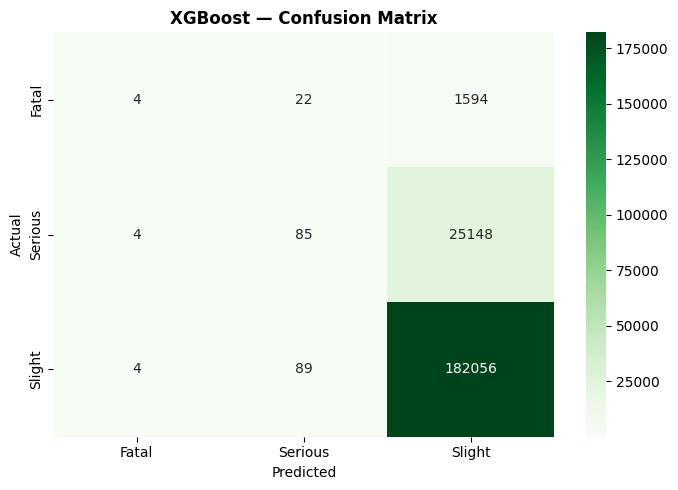


Classification Report:
              precision    recall  f1-score   support

       Fatal       0.33      0.00      0.00      1620
     Serious       0.43      0.00      0.01     25237
      Slight       0.87      1.00      0.93    182149

    accuracy                           0.87    209006
   macro avg       0.55      0.34      0.31    209006
weighted avg       0.81      0.87      0.81    209006



In [ ]:
# Confusion Matrix — XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fatal', 'Serious', 'Slight'],
            yticklabels=['Fatal', 'Serious', 'Slight'])
plt.title('XGBoost — Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb, target_names=['Fatal', 'Serious', 'Slight']))

## 9. Model Comparison

           Random Forest  XGBoost
Metric                           
Accuracy          0.8693   0.8715
Precision         0.7958   0.8148
Recall            0.8693   0.8715
F1-Score          0.8136   0.8125


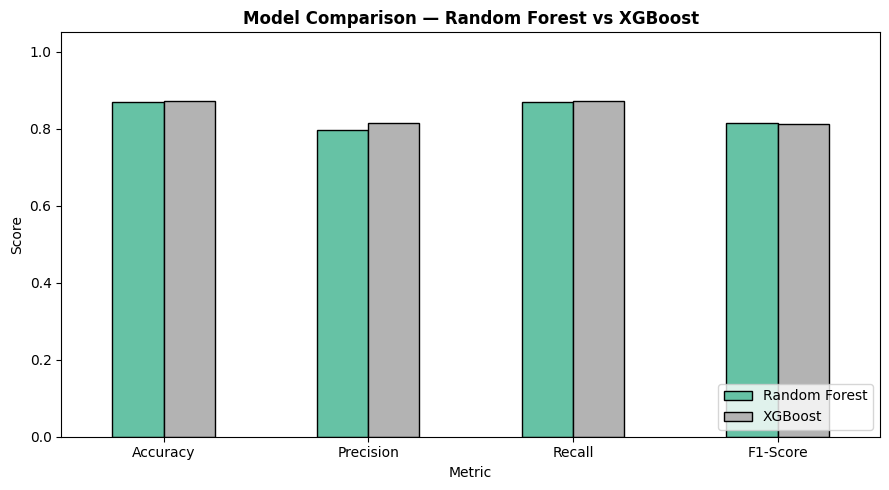

In [ ]:
# Side-by-side comparison
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1],
    'XGBoost':       [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]
})
comparison_df = comparison_df.set_index('Metric')
print(comparison_df.round(4).to_string())

# Bar chart comparison
comparison_df.plot(kind='bar', figsize=(9, 5), colormap='Set2', edgecolor='black')
plt.title('Model Comparison — Random Forest vs XGBoost', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 11. Conclusions & Business Insights

### ✅ Model Performance Summary

| Model         | Accuracy | Precision | Recall | F1-Score |
|---------------|----------|-----------|--------|----------|
| Random Forest | 86.93%   | 79.58%    | 86.93% | 81.36%   |
| XGBoost       | 87.15%   | 81.48%    | 87.15% | 81.25%   |

> XGBoost achieves slightly higher accuracy and precision.
> Random Forest offers better interpretability via feature importance.

---

### 🔍 Key Findings

1. **Class Imbalance is the core challenge** — Slight accidents dominate (80%+),
   making it hard to correctly classify Fatal and Serious cases.
   Future work: apply SMOTE or class_weight balancing.

2. **Both models perform comparably (~87%)** — XGBoost edges ahead on accuracy
   and precision; Random Forest leads slightly on F1.

3. **Feature selection with LinearSVC** reduced dimensionality effectively,
   keeping only the most predictive features and speeding up training.

---

### 💼 Business Recommendations

- 🚑 **Emergency Services** — Deploy this model to pre-position ambulances
  in high-risk zones during peak hours identified by the model.

- 🛣️ **Road Authorities** — Prioritize safety improvements on road types
  and conditions most associated with Fatal/Serious predictions.

- 📋 **Insurance Companies** — Use severity prediction as a risk-scoring
  input for policy pricing and claims triage.

- 📊 **Next Steps:**
  - Apply SMOTE to improve recall for Fatal class
  - Try LightGBM or CatBoost for further gains
  - Deploy as a REST API for real-time prediction
"""